In [1]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec  #grid pels subplots
from matplotlib import colors         #colors
from matplotlib.colors import LogNorm   #normalitza a 0-1 en escala logarítmica 
from matplotlib import patches     #figures
from mpl_toolkits.mplot3d import Axes3D   #eixos en 3D
from mpl_toolkits.axes_grid1 import make_axes_locatable  #per canviar la posició dels eixos
from matplotlib.ticker import NullFormatter   #marques(tics) sense etiquetes en els eixos

from astroML.density_estimation import XDGMM
from astroML.plotting.tools import draw_ellipse
from astroML.plotting import scatter_contour
from astroML.crossmatch import crossmatch
from astroML.datasets import fetch_sdss_S82standards, fetch_imaging_sample
from astroML.stats import sigmaG
from astroML.utils.decorators import pickle_results
import os
import pickle

import astropy.table     #paquet per manejar taules de dades
from astropy.table import Table, Column, MaskedColumn   #importa taules, columnes i columnes que emmascaren dades invàlides
from astropy.visualization import astropy_mpl_style  #visualització 
from scipy.stats import gaussian_kde  #representation of a kernel-density estimate using Gaussian kernels.
import seaborn as sns  #llibreria per fer gràfics estadístics
import os.path   #per implementar diferents funcions amb pathnames ("dreceres")

from time import time   #mòdul de funcions de time access 
from sklearn import manifold, datasets #manifold: algoritme de dimensionality reduction 
                                       #sklearn (sci-kit learn): llibreria de Python per machine learning
import umap                #Uniform Manifold Approximation and Projection (UMAP) is a dimensionality reduction technique
from sklearn.decomposition import PCA  #Principal component analysis (PCA). Linear dimensionality reduction using Singular Value    
from sklearn.manifold import TSNE #t-SNE [1] is a tool to visualize high-dimensional data
from itertools import product   #producte cartesià

import obtain_data   #per importar dades d'altres fitxers


In [2]:
import importlib   #package per importar coses a python
importlib.reload(obtain_data)

ck = ["k", "r", "gold", "g", "b",
          "orange", "cyan", "lime", "m", "yellow",
          "indianred", "hotpink", "peru", "cornflowerblue", "olivedrab",
          "grey", "turquoise", "lightpink", "navy", "khaki",
          "darkgreen", "crimson", "deepskyblue", "sandybrown", "limegreen",
          "deeppink", "dodgerblue", "rebeccapurple", "teal", "magenta"]

galah_rc = obtain_data.galah_dr3_rc()  

galah_rc.get_ndimspace(feh=True, norm="stdev")

X = galah_rc.X            #(10941, 24)
Xerr = galah_rc.Xerr1         #(10941, 24)
Xcov = np.zeros(Xerr.shape + Xerr.shape[-1:])
Xcov[:, range(Xerr.shape[1]), range(Xerr.shape[1])] = Xerr ** 2    #(10941, 24, 24)

@pickle_results('XD_5clusters.pkl')
def compute_XD(n_components, rseed=0, max_iter=100, verbose=True):
    np.random.seed(rseed)
    clf = XDGMM(n_components, max_iter=max_iter, tol=1E-5, verbose=verbose)
    clf.fit(X, Xcov) 
    return clf
# Fit the model on training set
clf = compute_XD(5)

# Probabilities for each star to belong to each group
logprob = (clf.logprob_a(X, Xcov))
prob_per_star = np.exp(logprob) / np.sum(np.exp(logprob), axis=1)[:, np.newaxis]  #(10941 estrelles, 5 probs)
maxprob_per_star = np.argmax(prob_per_star, axis=1)


@pickle_results: using precomputed results from 'XD_5clusters.pkl'


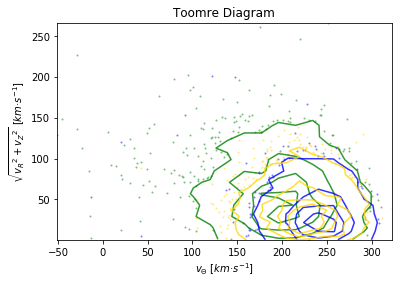

In [47]:
plt.title("Toomre Diagram")
plt.xlabel("$v_{\Theta}\ [km·s^{-1}]$")
plt.ylabel("$\sqrt{{v_R}^2 + {v_Z}^2}\ [km·s^{-1}]$")
for ii in [3,4,2,0,1]:
    x = galah_rc.data['vT_Rzphi'][maxprob_per_star==ii]
    y = np.sqrt(((galah_rc.data['vR_Rzphi'][maxprob_per_star==ii])**2) + ((galah_rc.data['vz_Rzphi'][maxprob_per_star==ii])**2))
    if ii in [3,4,2]:
        scatter_contour(x,y,levels=5,
                        threshold=5,
                        log_counts=0,
                        histogram2d_args=dict(bins=20,),
                        plot_args=dict(marker='o',
                                       linestyle='none',
                                       markeredgewidth=0,
                                       color=ck[ii],
                                       alpha=.5,#1-clf.alpha[ii],
                                       markersize=2),
                        contour_args=dict(cmap=None,  #cmap=plt.cm.Blues,
                                          colors=ck[ii],
                                          alpha=0.8),
                        filled_contour=False,
                        ax=None)
    #else:
    #    plt.scatter(x,y,color=ck[ii], s=1)
    
plt.savefig("../im/final_im/toomre.png", dpi=200)

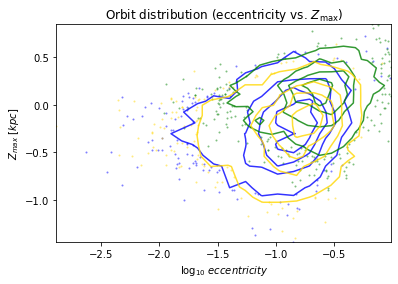

In [46]:
plt.title(r"Orbit distribution (eccentricity vs. $Z_{\rm max}$)")
plt.xlabel("$\log_{10}\ eccentricity$")
plt.ylabel("$Z_{max}\ [kpc]$")
for ii in [4,3,2]:
    x = np.log10(galah_rc.data["ecc"][maxprob_per_star==ii])
    y = np.log10(galah_rc.data["zmax"][maxprob_per_star==ii])
  
    scatter_contour(x,y,levels=5,
                threshold=5,
                log_counts=0,
                histogram2d_args=dict(bins=20,),
                plot_args=dict(marker='o',
                               linestyle='none',
                               markeredgewidth=0,
                               color=ck[ii],
                               alpha=.5,
                               markersize=2),
                contour_args=dict(cmap=None,colors=ck[ii],
                                  alpha=0.8),
                filled_contour=False,
                ax=None)
    
plt.savefig("../im/final_im/z_max(ecc).png", dpi=200)

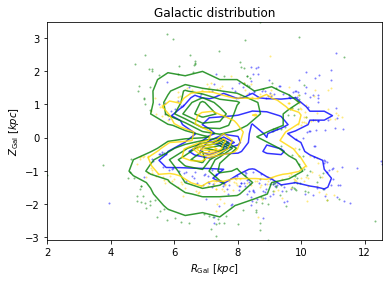

In [49]:
plt.title("Galactic distribution")
plt.xlabel(r"$R_{\rm Gal}\ [kpc]$")
plt.ylabel(r"$Z_{\rm Gal}\ [kpc]$")
for ii in [4,3,2]:
    x = galah_rc.data["R_Rzphi"][maxprob_per_star==ii]
    y = galah_rc.data["z_Rzphi"][maxprob_per_star==ii]

    scatter_contour(x,y,levels=6,
                    threshold=6,
                    log_counts=0,
                    histogram2d_args=dict(bins=20,),
                    plot_args=dict(marker='o',
                                   linestyle='none',
                                   markeredgewidth=0,
                                   color=ck[ii],
                                   alpha=.5,
                                   markersize=2),
                    contour_args=dict(cmap=None,colors=ck[ii],
                                      alpha=0.8),
                    filled_contour=False,
                    ax=None)
plt.savefig("../im/final_im/Z(R).png", dpi=200)